<font size="+3"><strong>Bankruptcy-In-Taiwan</strong></font>


# Import 

In [62]:
# import librairies
import zipfile
import pickle
import json 

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import(
classification_report,
ConfusionMatrixDisplay
) 
from imblearn.over_sampling import RandomOverSampler 
from sklearn.ensemble import RandomForestClassifier


In [43]:
# Load the compressed data
def wrangle(file_path):
    with zipfile.ZipFile(file_path, "r") as z:
        # Load the unzip data into a dataframe
        with z.open("data.csv") as f:
            df = pd.read_csv(f).rename_axis("company_id")

            return df


In [44]:
df = wrangle("C:/ML_Projects_Repositories/bankruptcy-in-taiwan/data/taiwanese+bankruptcy+prediction.zip")
print(df.shape)
# [f"feat_{i}" for i in range(1, 97)]
df.head()

(6819, 96)


,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
company_id,,,,,,,,,,,,,,,,,,,,,
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


## Feature Engnineering

In [45]:
actual_name = df.columns[1:] 
new_name = [f"feat_{i}" for i in range(1, 96)]

# zip method to link them
cols_names = dict(zip(actual_name, new_name))

# Rename dataset columns
df.rename(columns=cols_names, inplace=True)

# Rename target column
df.rename(columns={"Bankrupt?": "bankrupt"}, inplace=True) 

df.head(5)


,bankrupt,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95
company_id,,,,,,,,,,,,,,,,,,,,,
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


# _Exploratory Data Analysis (EDA)_

In [24]:
df.describe()

,bankrupt,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


Is there missing values ?

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   bankrupt  6819 non-null   int64  
 1   feat_1    6819 non-null   float64
 2   feat_2    6819 non-null   float64
 3   feat_3    6819 non-null   float64
 4   feat_4    6819 non-null   float64
 5   feat_5    6819 non-null   float64
 6   feat_6    6819 non-null   float64
 7   feat_7    6819 non-null   float64
 8   feat_8    6819 non-null   float64
 9   feat_9    6819 non-null   float64
 10  feat_10   6819 non-null   float64
 11  feat_11   6819 non-null   float64
 12  feat_12   6819 non-null   float64
 13  feat_13   6819 non-null   float64
 14  feat_14   6819 non-null   float64
 15  feat_15   6819 non-null   float64
 16  feat_16   6819 non-null   float64
 17  feat_17   6819 non-null   float64
 18  feat_18   6819 non-null   float64
 19  feat_19   6819 non-null   float64
 20  feat_20   6819 non-null   float64
 21  fe

### Is the data imbalanced ?

Text(0.5, 1.0, 'Class Balance')

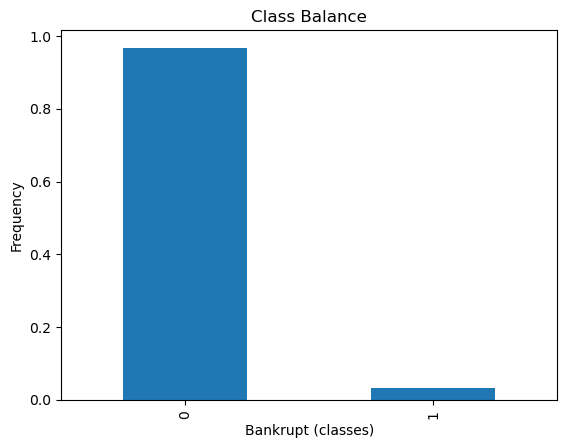

In [47]:
fix, ax= plt.subplots()  

# Plot bar chart
df["bankrupt"].value_counts(normalize=True).plot(kind="bar", ax=ax)

# X-axis
ax.set_xlabel("Bankrupt (classes)")

#Y-axis
ax.set_ylabel("Frequency")

# Title
ax.set_title("Class Balance")


The graph above shows an imbalanced dataset. That means the majority class is much further higher than the minority class  

In [46]:
corr = df.corr()["bankrupt"].abs()
corr.sort_values(ascending=False).head(5)

bankrupt    1.000000
feat_86     0.315457
feat_2      0.282941
feat_3      0.273051
feat_1      0.260807
Name: bankrupt, dtype: float64

Since there is a pretty strong correlation between **ROA(A) before interest and percentage after tax** and our target **Bankrupt** it's worth visualizing its distribution across both classes in bankrupt column.

Text(0.5, 1.0, 'Distribution of Return on Assets (ROA), by class')

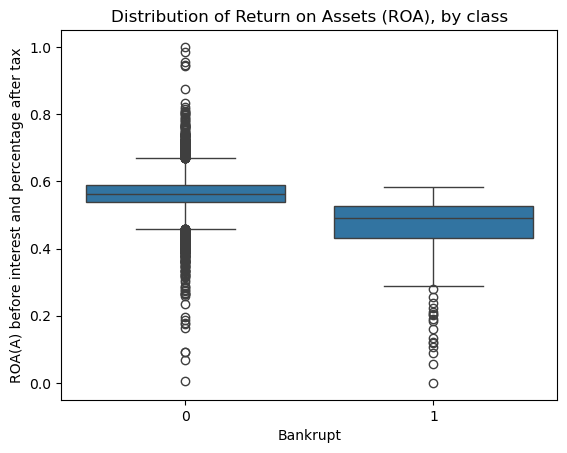

In [48]:
sns.boxplot(x="bankrupt", y="feat_2", data= df)

plt.xlabel("Bankrupt")
plt.ylabel("ROA(A) before interest and percentage after tax")
plt.title("Distribution of Return on Assets (ROA), by class")

<Axes: xlabel='feat_2', ylabel='Count'>

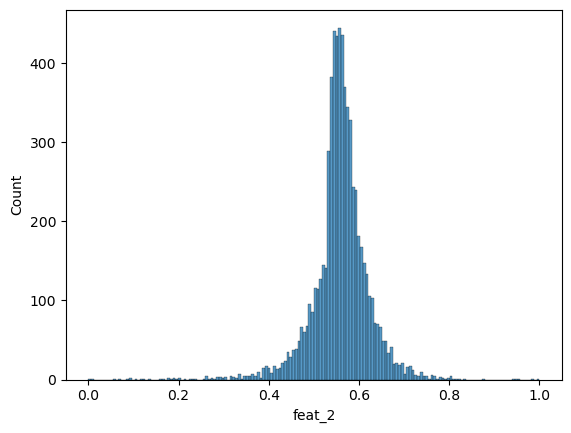

In [29]:
sns.histplot(df["feat_2"]) 

In [30]:
df.groupby("bankrupt")["feat_2"].agg(["mean", "median", "std"])

,mean,median,std
bankrupt,,,
0,0.562015,0.561219,0.060898
1,0.456947,0.490215,0.107674


In [31]:
df["feat_2"].describe()

count    6819.000000
mean        0.558625
std         0.065620
min         0.000000
25%         0.535543
50%         0.559802
75%         0.589157
max         1.000000
Name: feat_2, dtype: float64

<Axes: >

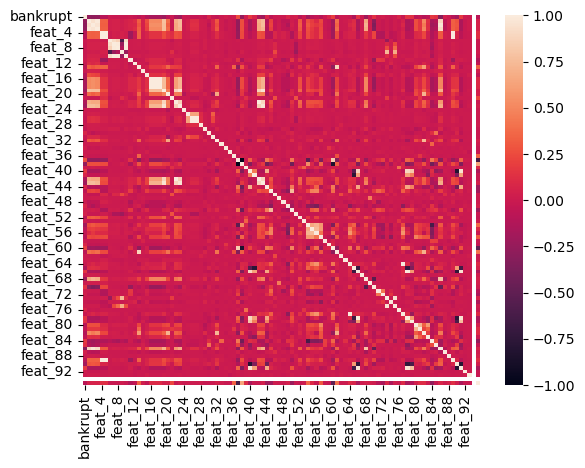

In [32]:
auto_corr = df.select_dtypes(include="number").corr()
sns.heatmap(auto_corr)

what's the EDA is telling ? First, our data is imbalanced. The box plot and the summary statistics related to **feat_2** show a slightly left-skewed distribution. They also indicate that bankrupt firms have a lower **ROA (return on assets)** profitability than non-bankrupt firms. This suggets that ROA may be a good feature to consider in estimating whether or not a company will go bankrupt in Taiwan. Finally, we have a multicollinearity issue, which means we should steer clear of linear models, and consider tree-based models instead.

# Split

In [49]:
target = "bankrupt"
X = df.drop(columns=target)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6819, 95)
y shape: (6819,)


In [50]:
# random split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5455, 95)
y_train shape: (5455,)
X_test shape: (1364, 95)
y_test shape: (1364,)


## Resample

Now we need to adress the imbalanced dataset issue before training our model. As resampling technique, we decided to choose the over_sampling method. it involves increasing the number of observations in the minority class by randomly making copy of the existing observations. 

In [51]:
over_sampler = RandomOverSampler(random_state=42)

X_train_over, y_train_over = over_sampler.fit_resample(X_train, y_train)

print("X_train_over", X_train_over.shape)
print("y_train_over", y_train_over.shape)
X_train_over.head()

X_train_over (10572, 95)
y_train_over (10572,)


,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_86,feat_87,feat_88,feat_89,feat_90,feat_91,feat_92,feat_93,feat_94,feat_95
0,0.498513,0.542848,0.544622,0.599194,0.599036,0.998986,0.797412,0.809330,0.303528,0.781593,...,0.801313,0.005821,0.623649,0.599196,0.840580,0.282564,0.027239,0.566658,1,0.022512
1,0.506606,0.562309,0.558863,0.609334,0.609334,0.999027,0.797450,0.809375,0.303508,0.781637,...,0.810914,0.000481,0.623932,0.609332,0.841339,0.280570,0.026843,0.565395,1,0.026670
2,0.508799,0.561001,0.554687,0.614242,0.614055,0.999094,0.797533,0.809424,0.303514,0.781692,...,0.809740,0.001397,0.623714,0.614241,0.840969,0.277772,0.026864,0.565484,1,0.041556
3,0.499976,0.562527,0.546764,0.597825,0.597825,0.999004,0.797411,0.809329,0.303490,0.781590,...,0.810082,0.000998,0.623986,0.597824,0.841885,0.286871,0.026951,0.565820,1,0.018173
4,0.477892,0.547700,0.529150,0.600362,0.600362,0.998975,0.797412,0.809333,0.303551,0.781584,...,0.804638,0.002826,0.623845,0.600363,0.840885,0.282073,0.026959,0.565848,1,0.023328


# Build Model

## Baseline

In [54]:
baseline_model_acc = df["bankrupt"].value_counts(normalize=True).max()
print("Baseline model:", round(baseline_model_acc, 4))

Baseline model: 0.9677


# Iterate

we just build the baseline model, let's see if the actual model can beat it  

In [55]:
clf = RandomForestClassifier(random_state=42)

## Hyperparameter Tuning 

Now we have our model created, let's find the best paramaters for our model 

In [56]:
# paramater setting
params = {
    "max_depth": range(10, 50, 10),
    "n_estimators": range(25, 100, 25)
}

params

{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}

We setted up our hyperparameter grid, let's incorporate it into GridSearch cross validation  

In [57]:
model = GridSearchCV(
    clf,
    param_grid=params,
    cv=5,
    n_jobs=-1,
    verbose=1,
)
model

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

Finally, now let's fit the over_sampling training data to the best model given after testting different parameters combination on five subset of trai

In [58]:
model.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': range(10, 50, 10), 'n_estimators': range(25, 100, 25)}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

Now that our model is trained, let's check the cross-validation results into DataFrame from the model and take look at which combination of **max_depth** and **n_estimator** gave us the best model.  

In [59]:
cv_results = pd.DataFrame(model.cv_results_)
cv_results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,2.049251,0.117565,0.043617,0.009771,10,25,"{'max_depth': 10, 'n_estimators': 25}",0.979196,0.977778,0.980132,0.978713,0.979659,0.979096,0.000811,11
1,3.857556,0.208429,0.051784,0.009495,10,50,"{'max_depth': 10, 'n_estimators': 50}",0.979669,0.979196,0.980132,0.979186,0.979186,0.979474,0.000378,10
2,6.027560,0.128953,0.108204,0.006948,10,75,"{'max_depth': 10, 'n_estimators': 75}",0.979196,0.980142,0.977294,0.979659,0.978713,0.979001,0.000977,12
3,2.637477,0.078852,0.048156,0.003339,20,25,"{'max_depth': 20, 'n_estimators': 25}",0.985816,0.985816,0.990066,0.988647,0.988647,0.987798,0.001700,9
4,5.134495,0.160142,0.075068,0.010476,20,50,"{'max_depth': 20, 'n_estimators': 50}",0.987234,0.987707,0.989120,0.990066,0.987701,0.988366,0.001060,8
5,7.012728,0.507342,0.117748,0.014235,20,75,"{'max_depth': 20, 'n_estimators': 75}",0.987234,0.988180,0.990066,0.989120,0.988174,0.988555,0.000963,7
6,2.718683,0.346349,0.048973,0.009127,30,25,"{'max_depth': 30, 'n_estimators': 25}",0.992435,0.992908,0.991958,0.991485,0.991485,0.992054,0.000553,6
7,5.433136,0.292626,0.101651,0.017558,30,50,"{'max_depth': 30, 'n_estimators': 50}",0.992435,0.992908,0.993377,0.994324,0.992431,0.993095,0.000707,5
8,7.684302,0.150227,0.106917,0.009764,30,75,"{'max_depth': 30, 'n_estimators': 75}",0.992435,0.992908,0.993377,0.994324,0.992904,0.993190,0.000641,4
9,2.574441,0.172941,0.047481,0.008755,40,25,"{'max_depth': 40, 'n_estimators': 25}",0.992908,0.994326,0.993851,0.993851,0.994797,0.993946,0.000627,3


In [60]:
model.best_params_ 

{'max_depth': 40, 'n_estimators': 50}

# Evaluate

First of all, let's evaluate our model by computing the accuracy score on the training and test data

In [61]:
acc_score_train = model.score(X_train, y_train)
acc_score_test = model.score(X_test, y_test)

print("model Training accuracy score:", round(acc_score_train, 4))
print("model test accuracy score:", round(acc_score_test, 4))

model Training accuracy score: 1.0
model test accuracy score: 0.9663


we can notice that the training accuracy is very high that's due the imbalanced dataset issue. Thus, let's evaluate our model further to see what's our model really did well and what's it didn't. Since we are facing a classfication problem we'll be using **Confusion Matrix** and **Classification Report** on the test set for further analysis.   

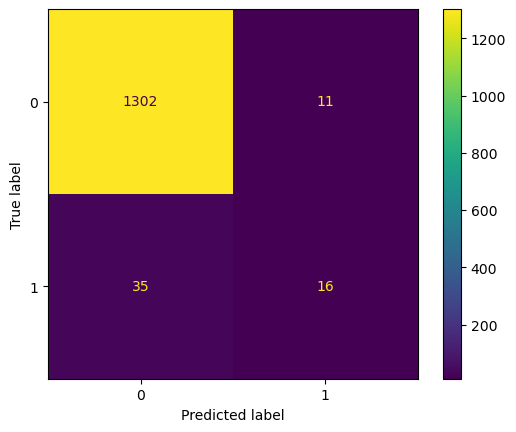

In [64]:
fig, ax = plt.subplots()
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax)

In [66]:
class_report = classification_report(y_test, model.predict(X_test))

print(class_report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1313
           1       0.59      0.31      0.41        51

    accuracy                           0.97      1364
   macro avg       0.78      0.65      0.70      1364
weighted avg       0.96      0.97      0.96      1364



Our model is somehow performing well. Since this project isn't related with a business decision-making, **Precision** and **Recall** performance metrics don't make too much sense. If it was, We'll be considering **Recall** when the false negative are more expensive than the false positive, and **Precision** when it's very significant for model's positive classifications or preditions to be accurate.   

# Communicate

Now that our model is trained and evaluted; let's communicate and show how important was each feature in predicting bankrupt and non-bankrupt company in TAIWAN   

In [1]:
best_model = model.best_estimator_

NameError: name 'model' is not defined